In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import sys
import os
from einops import repeat, rearrange
import pathlib
import yaml
import math
# Get the directory containing this notebook (notebooks/)
notebook_dir = pathlib.Path().resolve()
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))
print(f"Added to Python path: {project_root}")

from crate_implementation.models import CRATEClassification
from crate_implementation.utils import CodingRate, cal_sparsity, remove_all_hooks

# Check for available device (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")


Added to Python path: /Users/kelng/Documents/GitHub
Using device: mps


# Project Introduction

This project is to demonstrate several key ideas illustrated in the textbook "Learning Deep Representations of Data Distribution". More specifically the following:

1. How to derive Transformer like architecture from unrolled optimization of a compressive objective function
2. How to obtain image patch representation that is useful for segmentation by just training the model to do classification
3. What benefits do we gain from whitebox understanding of Transformer
3. Explain more on the connection between Transformer and diffusion-denoising

# Derivation of Transformer like neural network from sparse rate reduction.

(To be inserted)

# Load the data

In [2]:
# Load Fashion-MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST mean and std
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")


Training samples: 60000
Test samples: 10000
Batch size: 64


In [3]:
from collections import Counter

def count_classes(dataloader):
    all_labels = []
    for _, labels in dataloader:
        all_labels.extend(labels.numpy())
    return Counter(all_labels)

train_class_counts = count_classes(train_loader)
test_class_counts = count_classes(test_loader)

# Print results
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training set class distribution:")
for i in range(10):
    print(f"  Class {i} ({class_names[i]}): {train_class_counts[i]} samples")

print("\nTest set class distribution:")
for i in range(10):
    print(f"  Class {i} ({class_names[i]}): {test_class_counts[i]} samples")

Training set class distribution:
  Class 0 (T-shirt/top): 6000 samples
  Class 1 (Trouser): 6000 samples
  Class 2 (Pullover): 6000 samples
  Class 3 (Dress): 6000 samples
  Class 4 (Coat): 6000 samples
  Class 5 (Sandal): 6000 samples
  Class 6 (Shirt): 6000 samples
  Class 7 (Sneaker): 6000 samples
  Class 8 (Bag): 6000 samples
  Class 9 (Ankle boot): 6000 samples

Test set class distribution:
  Class 0 (T-shirt/top): 1000 samples
  Class 1 (Trouser): 1000 samples
  Class 2 (Pullover): 1000 samples
  Class 3 (Dress): 1000 samples
  Class 4 (Coat): 1000 samples
  Class 5 (Sandal): 1000 samples
  Class 6 (Shirt): 1000 samples
  Class 7 (Sneaker): 1000 samples
  Class 8 (Bag): 1000 samples
  Class 9 (Ankle boot): 1000 samples


# Training

## Training Utils

In [4]:
# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Evaluating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


## Model Initialization

In [ ]:
# Training loop
num_epochs = 20
train_losses = []
train_accs = []
test_losses = []
test_accs = []
config_filename = 'crate_medium_deep'

# Model configuration
model_config = {
    'img_size': 28,
    'patch_size': 7,  # 7x7 patches -> 4x4 = 16 patches total
    'in_channels': 1,
    'embed_dim': 36,
    'num_classes': 10,
    'num_blocks': 12,
    'num_heads': 6,
    'dim_head': 6,  # 8 heads * 6 dim_head = 48 embed_dim
    'dropout': 0.1,
    'pool': 'cls'
}

# Initialize the model
model = CRATEClassification(**model_config).to(device)

# Setup training
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
warmup_steps = 20
lr_func = lambda step: min((step + 1) / (warmup_steps + 1e-8), 
                            0.5 * (math.cos(step / num_epochs * math.pi) + 1))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_func)


# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test forward pass
sample_batch = next(iter(train_loader))[0][:4].to(device)
with torch.no_grad():
    output = model(sample_batch)
    print(f"\nSample input shape: {sample_batch.shape}")
    print(f"Sample output shape: {output.shape}")
    print(f"Sample predictions: {output.argmax(dim=1)}")


# Create checkpoints directory
notebook_dir = pathlib.Path().resolve()
checkpoints_dir = notebook_dir / 'checkpoints'
checkpoints_dir.mkdir(exist_ok=True)

# Create configs directory
configs_dir = notebook_dir / 'configs'
configs_dir.mkdir(exist_ok=True)
config_path = configs_dir / config_filename

# Save model configuration to YAML file
with open(config_path, 'w') as f:
    yaml.dump(model_config, f, default_flow_style=False, sort_keys=False)

Total parameters: 51,706
Trainable parameters: 51,706

Sample input shape: torch.Size([4, 1, 28, 28])
Sample output shape: torch.Size([4, 10])
Sample predictions: tensor([8, 8, 2, 2], device='mps:0')


In [8]:
# Visualize Model Structure with TensorBoard
from crate_implementation.utils import visualize_model_graph

# Create a sample input for visualization (single image, normalized)
sample_input = torch.randn(1, 1, 28, 28).to(device)

# Visualize the model structure
writer = visualize_model_graph(
    model=model,
    sample_input=sample_input,
    log_dir="runs/model_visualization",
    model_name="crate_fashion_mnist",
    verbose=True
)

# Close the writer (optional, but good practice)
writer.close()


Visualizing model structure...
Model: CRATEClassification
Sample input shape: torch.Size([1, 1, 28, 28])
Log directory: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/runs/model_visualization/crate_fashion_mnist

✓ Model graph successfully logged to TensorBoard!

To view the visualization, run:
  tensorboard --logdir=/Users/kelng/Documents/GitHub/crate_implementation/notebooks/runs/model_visualization

Then open your browser and navigate to: http://localhost:6006
Click on the 'GRAPHS' tab to view the model structure.


## Start training with options of from scratch or with loaded weights

In [9]:
# Optionally specify a checkpoint to resume from
# Set to None to start training from scratch
resume_checkpoint_path = None  # e.g., checkpoints_dir / 'crate_base_epoch_5.pt'

# Initialize training variables
start_epoch = 0
train_losses = []
train_accs = []
test_losses = []
test_accs = []

# Load checkpoint if resuming
if resume_checkpoint_path is not None and pathlib.Path(resume_checkpoint_path).exists():
    print(f"Loading checkpoint from: {resume_checkpoint_path}")
    checkpoint = torch.load(resume_checkpoint_path, map_location=device)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load optimizer state
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Load scheduler state
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    # Load training history
    if 'train_loss' in checkpoint:
        train_losses = checkpoint.get('train_losses', [])
        train_accs = checkpoint.get('train_accs', [])
        test_losses = checkpoint.get('test_losses', [])
        test_accs = checkpoint.get('test_accs', [])
    
    # Resume from the next epoch
    start_epoch = checkpoint['epoch']
    
    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous train acc: {checkpoint.get('train_acc', 'N/A'):.2f}%")
    print(f"Previous test acc: {checkpoint.get('test_acc', 'N/A'):.2f}%")
else:
    print("Starting training from scratch...")

print("Starting training...")
for epoch in range(start_epoch, num_epochs):
    current_epoch = epoch + 1  # True epoch number (1-indexed)
    print(f"\nEpoch {current_epoch}/{num_epochs}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Update learning rate
    scheduler.step()
    
    # Save checkpoint every 5 epochs
    if current_epoch % 5 == 0:
        config_name = pathlib.Path(config_path).stem  # e.g., "crate_fashion_mnist"
        
        # Use true epoch number in checkpoint filename
        checkpoint_path = checkpoints_dir / f'{config_name}_epoch_{current_epoch}.pt'
        
        checkpoint = {
            'epoch': current_epoch,  # True epoch number
            'model_state_dict': model.state_dict(),
            'model_config': model_config,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'learning_rate': scheduler.get_last_lr()[0],
            # Save full training history for potential future resumption
            'train_losses': train_losses,
            'train_accs': train_accs,
            'test_losses': test_losses,
            'test_accs': test_accs
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
    
    print(f"\nEpoch {current_epoch} Summary:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    
    print(f"\nTraining results:")
    print(f"  Best train accuracy: {max(train_accs):.2f}%")
    print(f"  Best test accuracy: {max(test_accs):.2f}%")

Starting training from scratch...
Starting training...

Epoch 1/20
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:04<00:00, 34.01it/s, loss=1.1995, acc=56.03%]



Epoch 1 Summary:
Train Loss: 1.7294, Train Acc: 38.20%
Test Loss: 1.2166, Test Acc: 56.03%
Learning Rate: 0.000100

Training results:
  Best train accuracy: 38.20%
  Best test accuracy: 56.03%

Epoch 2/20
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:04<00:00, 38.09it/s, loss=0.6271, acc=68.44%]



Epoch 2 Summary:
Train Loss: 1.0627, Train Acc: 62.19%
Test Loss: 0.8481, Test Acc: 68.44%
Learning Rate: 0.000150

Training results:
  Best train accuracy: 62.19%
  Best test accuracy: 68.44%

Epoch 3/20
--------------------------------------------------


...


Epoch 18 Summary:
Train Loss: 0.3873, Train Acc: 85.80%
Test Loss: 0.3793, Test Acc: 86.46%
Learning Rate: 0.000024

Training results:
  Best train accuracy: 85.80%
  Best test accuracy: 86.46%

Epoch 19/20
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:03<00:00, 39.89it/s, loss=0.3054, acc=86.43%]



Epoch 19 Summary:
Train Loss: 0.3806, Train Acc: 86.09%
Test Loss: 0.3730, Test Acc: 86.43%
Learning Rate: 0.000006

Training results:
  Best train accuracy: 86.09%
  Best test accuracy: 86.46%

Epoch 20/20
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:03<00:00, 39.77it/s, loss=0.3069, acc=86.44%]

Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/crate_medium_deep_epoch_20.pt

Epoch 20 Summary:
Train Loss: 0.3785, Train Acc: 86.15%
Test Loss: 0.3742, Test Acc: 86.44%
Learning Rate: 0.000000

Training results:
  Best train accuracy: 86.15%
  Best test accuracy: 86.46%


## Plot Losses

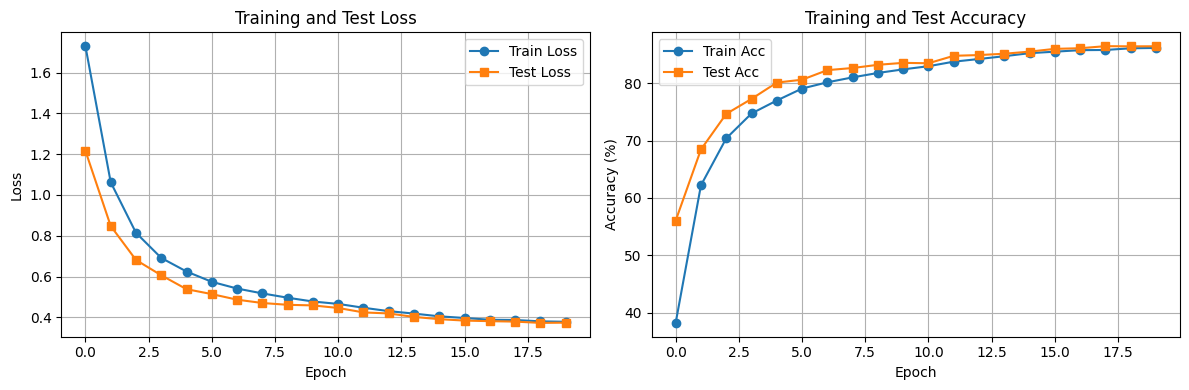


Final Results:
Best Train Accuracy: 86.15%
Best Test Accuracy: 86.46%


In [10]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(test_accs, label='Test Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Best Train Accuracy: {max(train_accs):.2f}%")
print(f"Best Test Accuracy: {max(test_accs):.2f}%")


# Load model for evaluation (if needed)

In [ ]:
model_path = pathlib.Path('models/crate_fashion_mnist_model.pt')

if model_path.exists():
    print(f"Loading model from: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    
    # Recreate model with saved configuration
    model_config = checkpoint['model_config']
    model = CRATEClassification(**model_config).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Load training history if available
    if 'training_history' in checkpoint:
        training_history = checkpoint['training_history']
        train_losses = training_history['train_losses']
        train_accs = training_history['train_accs']
        test_losses = training_history['test_losses']
        test_accs = training_history['test_accs']
        num_epochs = training_history['num_epochs']
        
        print(f"\nLoaded training history:")
        print(f"  Epochs trained: {num_epochs}")
        print(f"  Best train accuracy: {training_history['best_train_acc']:.2f}%")
        print(f"  Best test accuracy: {training_history['best_test_acc']:.2f}%")
    
    print("\nModel loaded successfully!")
    print(f"Model configuration:")
    for key, value in model_config.items():
        print(f"  {key}: {value}")
else:
    print(f"Model file not found at: {model_path}")
    print("Please train the model first or check the path.")


# Hook

In [11]:
def setup_model_hooks(model):
    """
    Set up forward hooks on the model to capture:
    - Coding rate from MSSA QKV outputs
    - Sparsity from ISTA outputs
    - Block outputs from ISTA
    - W values (reshaped QKV outputs) from MSSA
    
    Args:
        model: The CRATE model to attach hooks to
        
    Returns:
        tuple: (coding_rate_list, sparsity_list, block_outputs_list, w_list)
    """
    # Remove any existing hooks before registering new ones
    remove_all_hooks(model)
    
    coding_rate_list = []
    sparsity_list = []
    block_outputs_list = []
    # List to store w values
    w_list = []
    coding_rate = CodingRate()
    
    def forward_hook_codingrate(module, input, output):
        coding_rate_list.append(coding_rate(rearrange(output, 'b n (h d) -> b h n d', h=model.crate.blocks[0].mssa.heads)))
    
    def forward_hook_sparsity(module, input, output):
        sparsity_list.append(cal_sparsity(output.cpu().numpy(), is_sparse=True))
    
    def forward_hook_block_output(module, input, output):
        # Detach to avoid keeping gradients, move to CPU for visualization
        # Shape: [batch, seq_len, dim]
        block_outputs_list.append(output[:, 1:].detach().cpu())
    
    def forward_hook_w(module, input, output):
        # Capture the w tensor (reshaped QKV output) from MSSA module
        # Shape: [batch, heads, seq_len, dim_head]
        w_list.append(output.detach().cpu())
    
    # Register hooks on all blocks
    for block in model.crate.blocks:
        block.mssa.qkv.register_forward_hook(forward_hook_codingrate)
        block.ista.register_forward_hook(forward_hook_sparsity)
        # Register hook on the encoder block itself to capture its output
        block.ista.register_forward_hook(forward_hook_block_output)
        # Register hook on MSSA module to capture w tensor (reshaped QKV output)
        block.mssa.qkv.register_forward_hook(forward_hook_w)
    
    return coding_rate_list, sparsity_list, block_outputs_list, w_list



# Random batch evaluation

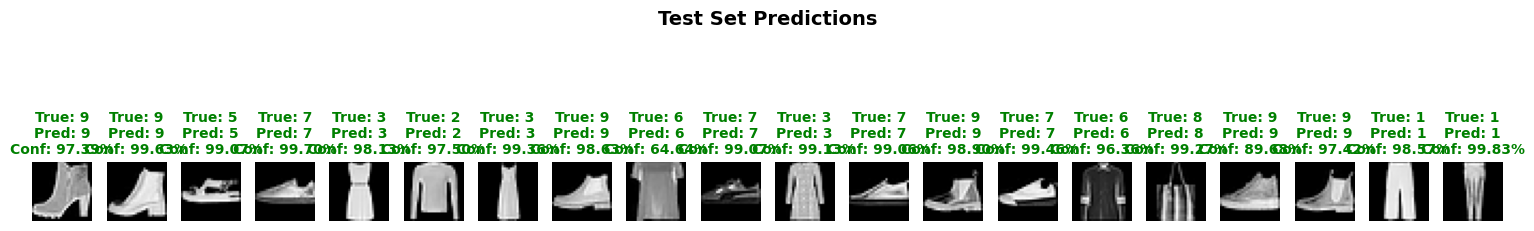


Prediction Summary:
Correct: 20/20
Accuracy: 100.0%


In [29]:
coding_rate_list, sparsity_list, block_outputs_list, w_list = setup_model_hooks(model)

# Visualize 5 predictions from test set
model.eval()

# Get 5 random samples from test set
num_samples = 20
sample_indices = torch.randint(0, len(test_dataset), (num_samples,))
samples = [test_dataset[i] for i in sample_indices]

# Prepare batch
images = torch.stack([sample[0] for sample in samples]).to(device)
true_labels = torch.tensor([sample[1] for sample in samples]).to(device)

# Make predictions
with torch.no_grad():
    outputs = model(images)
    probabilities = F.softmax(outputs, dim=1)
    predicted_labels = outputs.argmax(dim=1)
    confidence_scores = probabilities.max(dim=1)[0]

# Denormalize images for visualization
# Fashion-MNIST normalization: mean=0.2860, std=0.3530
mean = torch.tensor([0.2860], device=images.device)
std = torch.tensor([0.3530], device=images.device)
images_denorm = images * std.view(1, 1, 1, 1) + mean.view(1, 1, 1, 1)
images_denorm = torch.clamp(images_denorm, 0, 1)

# Move data to cpu for visualization and comparison
images_denorm = images_denorm.cpu()
true_labels_cpu = true_labels.cpu()
predicted_labels_cpu = predicted_labels.cpu()
confidence_scores_cpu = confidence_scores.cpu()

# Create visualization
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    ax = axes[i]
    img = images_denorm[i].squeeze().numpy()
    true_label = true_labels_cpu[i].item()
    pred_label = predicted_labels_cpu[i].item()
    confidence = confidence_scores_cpu[i].item()
    
    # Display image
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Color code: green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    
    # Add title with true label, prediction, and confidence
    title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}'
    ax.set_title(title, color=color, fontsize=10, fontweight='bold')

plt.suptitle('Test Set Predictions', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nPrediction Summary:")
correct = (predicted_labels_cpu == true_labels_cpu).sum().item()
print(f"Correct: {correct}/{num_samples}")
print(f"Accuracy: {100*correct/num_samples:.1f}%")


# Analysis

1. The $R^{c}\left(Z^{\ell+1/2}\mid U_{[K]}^{\ell}\right)$ of MSSA output and $\left\lVert Z^{\ell+1}\right\rVert_{0}$ of ISTA block output
2. Low-rankness of $Z$
3. Auto-correlation of subspaces in each layer $[U_1^{\ell},\ldots,U_K^{\ell}]^{*},[U_1^{\ell},\ldots,U_K^{\ell}] \in \mathbb{R}^{pK \times pK}$
4. Clustering [CLS] representation
5. Semantic meaning of each attention head
6. Self-attention map 
7. If there are $K$ classes for token representation, each class might be represented by a subset of columns in dictionary $D$. $U_[k]$ might be corresponding to a subset of column in $D$
8. Compare features of 1 and 7.

In [30]:
# Compute mean and standard deviation across all batches and heads
means = []
std_devs = []
for (mean, std) in coding_rate_list:
    means.append(mean.item())
    std_devs.append(std.item())

sparsities = []
std_sparsities = []
for (mean, std) in sparsity_list:
    sparsities.append(mean)
    std_sparsities.append(std)

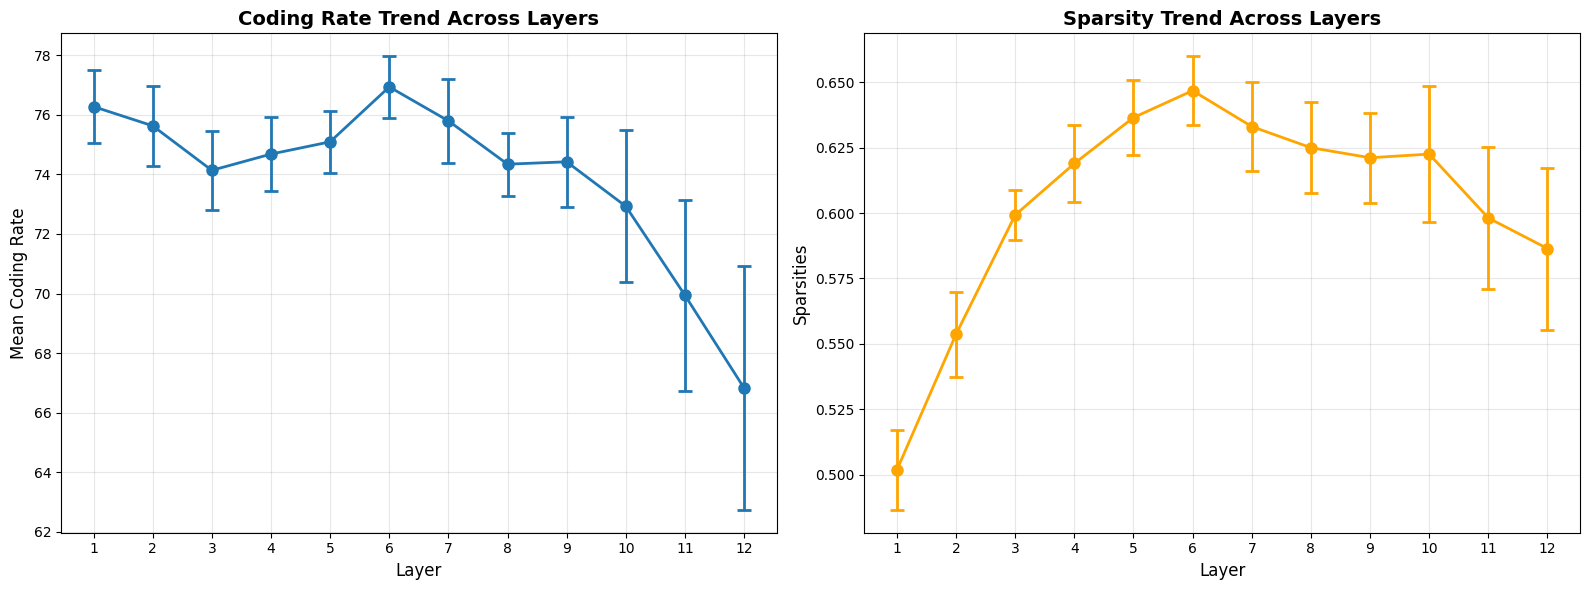

In [36]:
# Plot coding rate and sparsity trend across layers side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
layers = list(range(1, 13))  # 8 layers

# Coding Rate plot
axes[0].errorbar(
    layers, means, yerr=std_devs,
    marker='o', linestyle='-', linewidth=2, 
    markersize=8, capsize=5, capthick=2
)
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Mean Coding Rate', fontsize=12)
axes[0].set_title('Coding Rate Trend Across Layers', fontsize=14, fontweight='bold')
axes[0].set_xticks(layers)
axes[0].grid(True, alpha=0.3)

# Sparsity plot (use orange for the curve)
axes[1].errorbar(
    layers, sparsities, yerr=std_sparsities,
    marker='o', linestyle='-', linewidth=2, 
    color='orange',
    markersize=8, capsize=5, capthick=2
)
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Sparsities', fontsize=12)
axes[1].set_title('Sparsity Trend Across Layers', fontsize=14, fontweight='bold')
axes[1].set_xticks(layers)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Interpretation:

$R^{c}\left(Z^{\ell+1/2}\mid U_{[K]}^{\ell}\right)$ of MSSA outputs is decreasing from layer 1 to layer 12. That indicates the learnt token representation becomes more and more compressed against the representation subspace they should be in. 

On the other hand, we can see that the sparsity of learnt representation is higher than the raw image patches'. You may refer to the heatmap below for a better visualization on how sparse the token representations are.

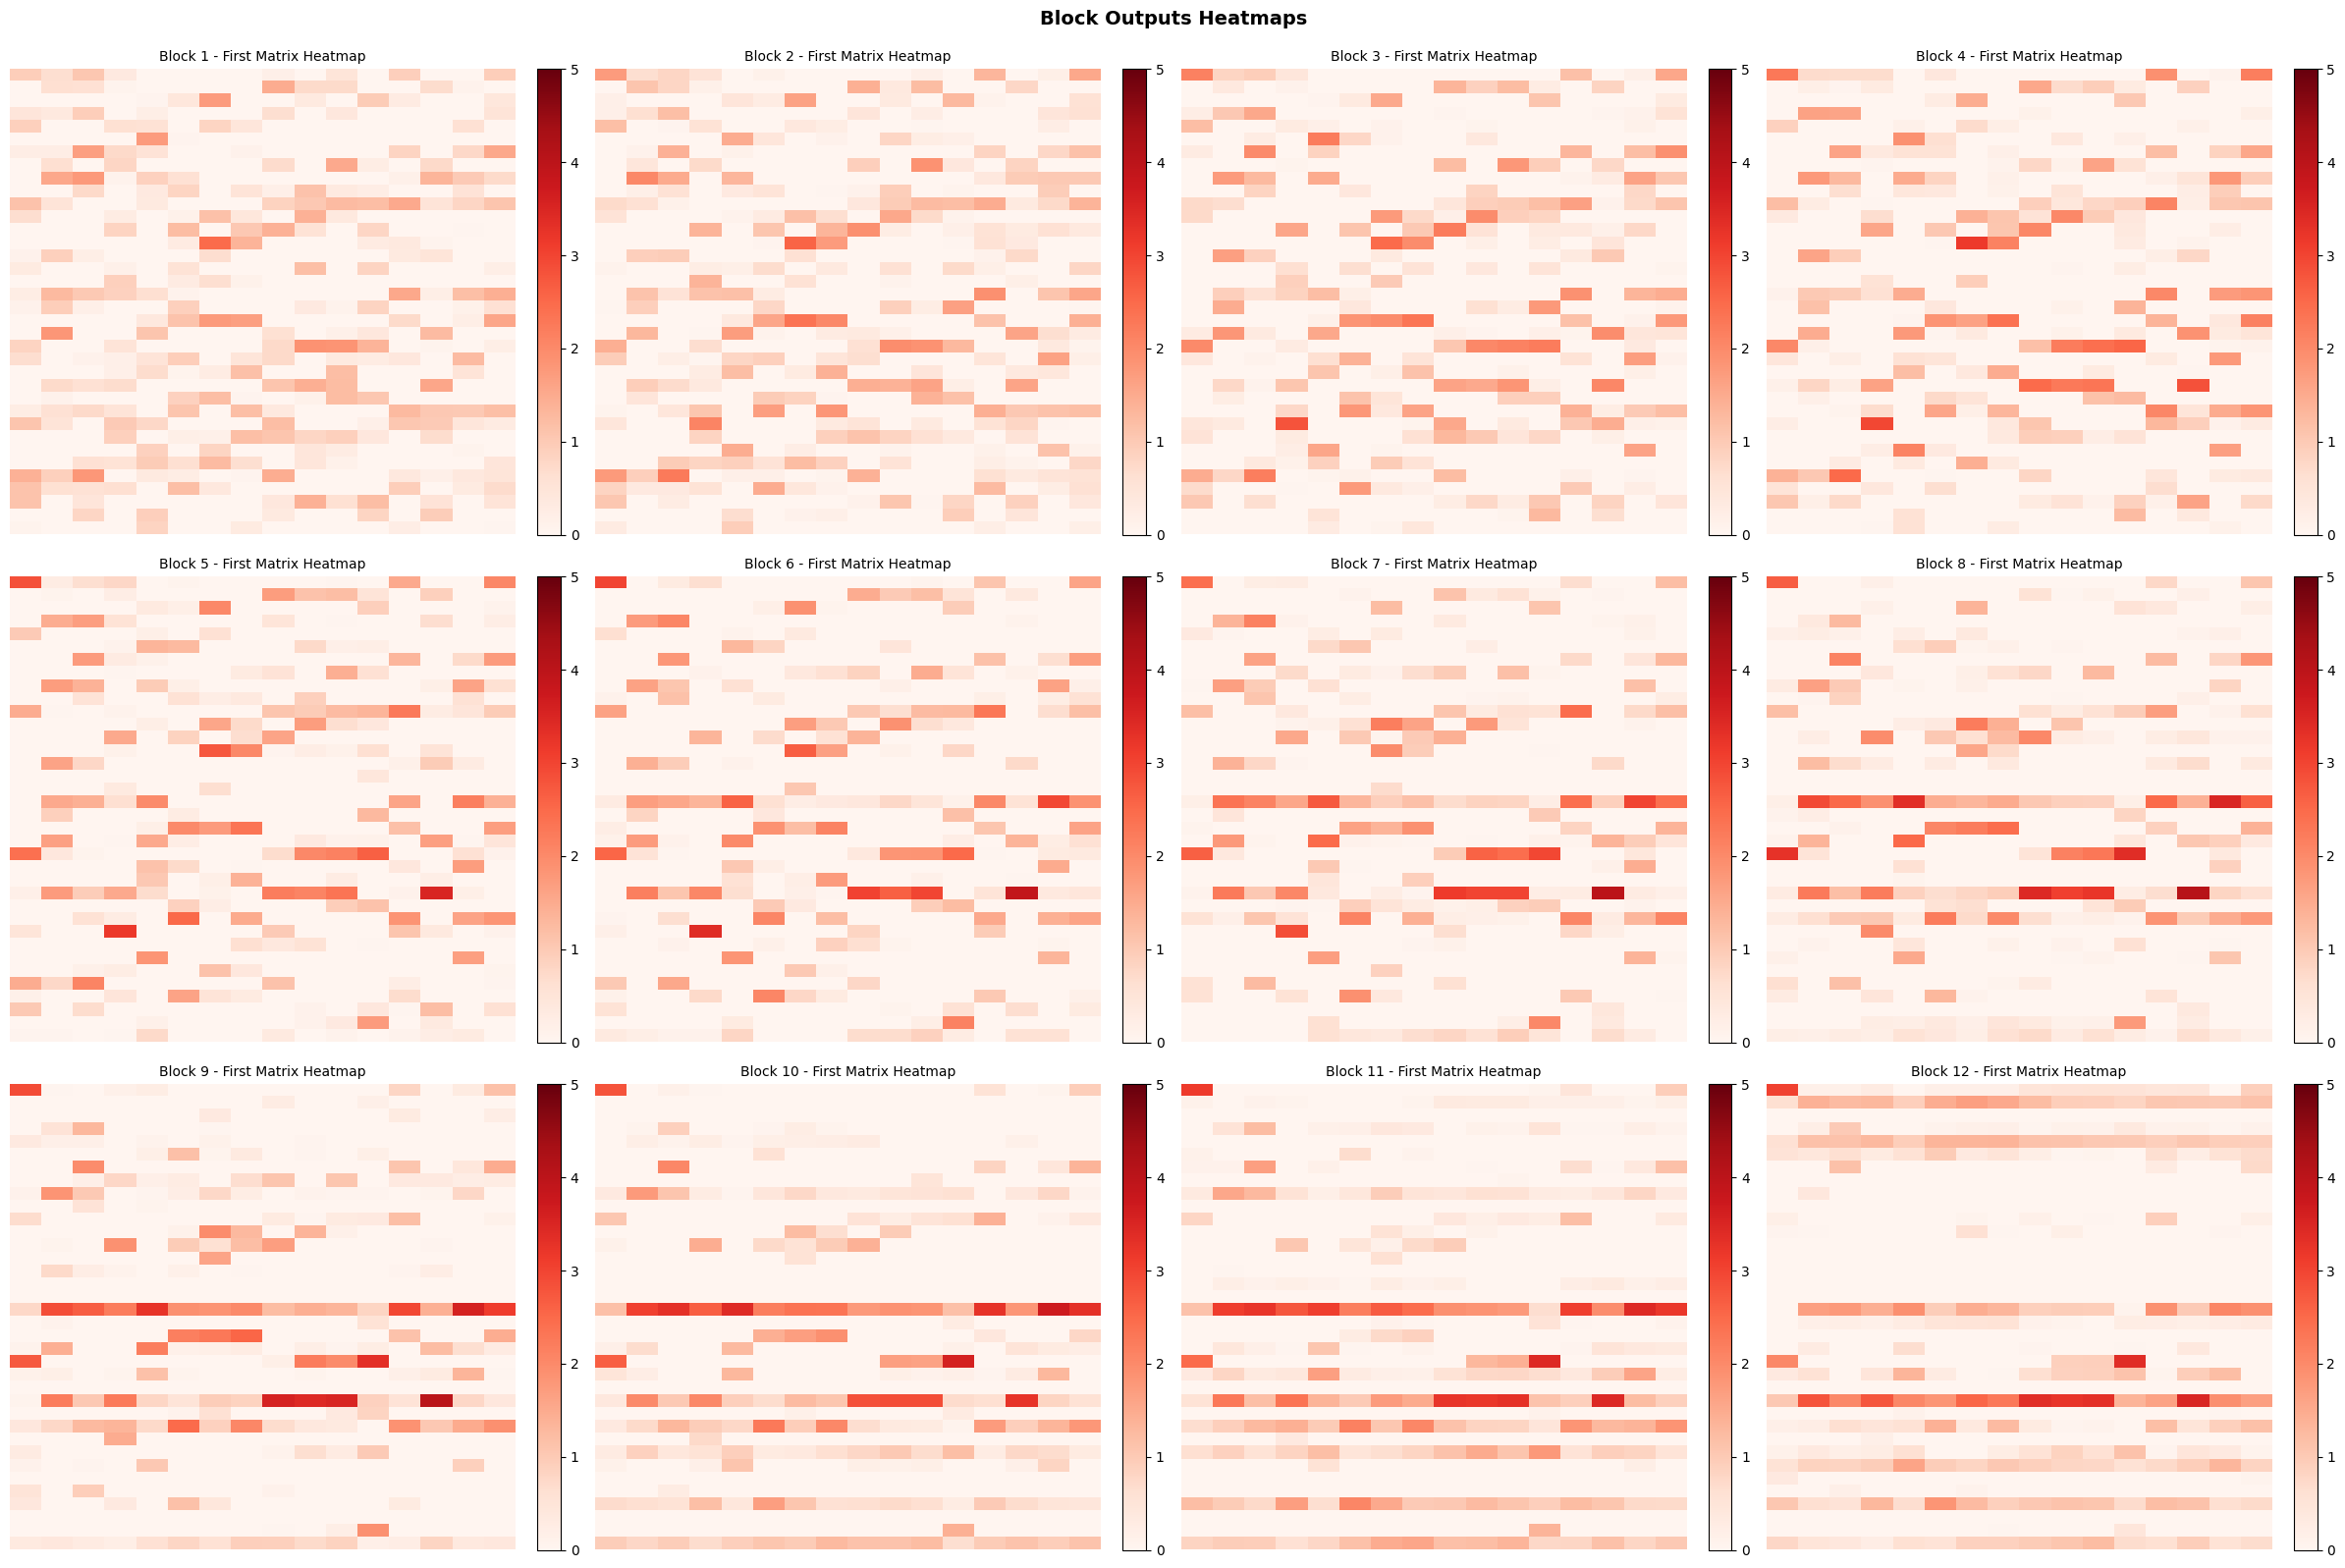

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Count how many blocks have data
num_blocks_with_data = sum(1 for block in block_outputs_list if len(block) > 0)

# Determine grid dimensions (2 rows, 4 columns for 8 blocks)
n_rows = 3
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

vmin, vmax = 0, 5
block_idx = 0

for i, block in enumerate(block_outputs_list):
    if len(block) > 0:
        matrix = block[3].T  # Take the first image representation for this block
        ax = axes[block_idx]
        
        im = ax.imshow(matrix, cmap='Reds', aspect='auto', vmin=vmin, vmax=vmax)
        ax.set_title(f'Block {i+1} - First Matrix Heatmap', fontsize=10)
        ax.axis('off')
        
        # Add colorbar to each subplot
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        block_idx += 1

# Hide unused subplots if any
for idx in range(block_idx, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Block Outputs Heatmaps', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

It is also as aspected that the subspaces represented by $U_{[K]}$ should become more and more incoherent.

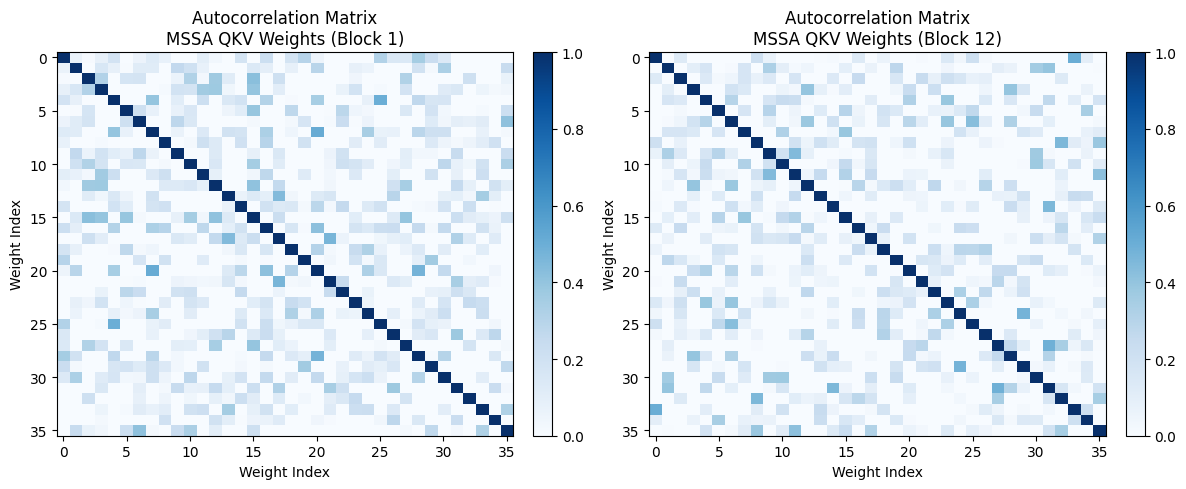

In [53]:
# # subspaces of the first and last layer side by side
import torch

# Prepare the weights for block 1 and block 8
qkv_weights_1 = model.crate.blocks[0].mssa.qkv.weight.data.cpu().numpy()
qkv_weights_8 = model.crate.blocks[-1].mssa.qkv.weight.data.cpu().numpy()

# Normalize each column (z-score normalization: subtract mean, divide by std)
# Transpose so columns become rows for np.corrcoef
qkv_weights_1_normalized = (qkv_weights_1 - qkv_weights_1.mean(axis=0)) / (qkv_weights_1.std(axis=0) + 1e-8)
qkv_weights_8_normalized = (qkv_weights_8 - qkv_weights_8.mean(axis=0)) / (qkv_weights_8.std(axis=0) + 1e-8)

# Compute autocorrelation for both (transpose so columns are treated as variables)
autocorr_matrix_1 = np.corrcoef(qkv_weights_1_normalized.T)
autocorr_matrix_8 = np.corrcoef(qkv_weights_8_normalized.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

vmin, vmax = 0, 1
im1 = axes[0].imshow(autocorr_matrix_1, cmap='Blues', aspect='auto', vmin=vmin, vmax=vmax)
axes[0].set_title("Autocorrelation Matrix\nMSSA QKV Weights (Block 1)")
axes[0].set_xlabel("Weight Index")
axes[0].set_ylabel("Weight Index")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(autocorr_matrix_8, cmap='Blues', aspect='auto', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Autocorrelation Matrix\nMSSA QKV Weights (Block {i+1})")
axes[1].set_xlabel("Weight Index")
axes[1].set_ylabel("Weight Index")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# Self attention map for each prediction

In [56]:
def visualize_cls_attention_maps(w_list, images, model_config, num_heads=None, 
                                 image_size=None, mean=0.2860, std=0.3530,
                                 verbose=True, show_plot=True):
    """
    Visualize CLS token attention maps overlaid on images.
    
    Parameters:
    -----------
    w_list : list
        List of block embeddings from model hooks. Uses w_list[-1] (last block).
    images : torch.Tensor
        Input images tensor of shape (batch_size, channels, height, width).
    model_config : dict
        Model configuration dictionary containing 'num_heads' and optionally 'img_size'.
    num_heads : int, optional
        Number of attention heads. If None, extracted from model_config['num_heads'].
    image_size : tuple, optional
        Target image size for upsampling (height, width). 
        If None, uses (model_config['img_size'], model_config['img_size']).
    mean : float, optional
        Mean value for denormalization. Default: 0.2860 (Fashion-MNIST).
    std : float, optional
        Standard deviation for denormalization. Default: 0.3530 (Fashion-MNIST).
    verbose : bool, optional
        Whether to print shape information. Default: True.
    show_plot : bool, optional
        Whether to display the plot. Default: True.
    
    Returns:
    --------
    attention_upsampled : torch.Tensor
        Upsampled attention maps of shape (batch_size, num_heads, height, width).
    attention_upsampled_np : numpy.ndarray
        Numpy array version of attention maps.
    images_denorm_np : numpy.ndarray
        Denormalized images as numpy array.
    """
    # Get number of heads from model_config if not provided
    if num_heads is None:
        num_heads = model_config['num_heads']
    
    # Get image size from model_config if not provided
    if image_size is None:
        img_size = model_config.get('img_size', 28)
        image_size = (img_size, img_size)
    
    # Get the last block's patch embeddings
    last_block_embeddings = w_list[-1]  # Shape: (b, n, d)
    if verbose:
        print(f"Original last block embeddings shape: {last_block_embeddings.shape}")
    
    # Rearrange to separate heads: (b, n, d) -> (b, h, n, d_head)
    # where d = h * d_head (e.g., 128 = 8 * 16)
    last_block_embeddings = rearrange(last_block_embeddings, 'b n (h d) -> b h n d', h=num_heads)
    if verbose:
        print(f"Rearranged last block embeddings shape: {last_block_embeddings.shape}")
    
    # Extract CLS token (first patch) for each image in the batch and each head
    emb_cls = last_block_embeddings[:, :, 0, :]  # Shape: (b, h, d)
    if verbose:
        print(f"CLS token shape: {emb_cls.shape}")
    
    # Extract all other patches (excluding CLS token) for each head
    other_patches = last_block_embeddings[:, :, 1:, :]  # Shape: (b, h, n-1, d)
    if verbose:
        print(f"Other patches shape: {other_patches.shape}")
    
    # Multiply CLS token with all other patches for each head
    # For each batch and head: compute dot product between CLS token and each patch
    # (b, h, 1, d) @ (b, h, d, n-1) -> (b, h, 1, n-1) -> squeeze -> (b, h, n-1)
    cls_similarities = torch.matmul(
        emb_cls.unsqueeze(2),  # Shape: (b, h, 1, d)
        other_patches.transpose(-1, -2)  # Shape: (b, h, d, n-1)
    ).squeeze(2)  # Shape: (b, h, n-1)
    if verbose:
        print(f"CLS similarities (dot product) shape: {cls_similarities.shape}")
    
    # Apply softmax to normalize similarities across patches for each head
    # Softmax over the patch dimension (dim=2) for each batch and head independently
    cls_attention_weights = F.softmax(cls_similarities, dim=-1)  # Shape: (b, h, n-1)
    if verbose:
        print(f"CLS attention weights (softmax) shape: {cls_attention_weights.shape}")
        print(f"CLS attention weights sum per batch and head (should be ~1.0):")
        print(cls_attention_weights.sum(dim=2))  # Shape: (b, h) - should be all ~1.0
    
    # Reshape attention weights and upsample to original image size
    batch_size, num_heads_actual, num_patches = cls_attention_weights.shape
    patch_grid_size = int(np.sqrt(num_patches))  # Should be 7 for 7x7 grid
    
    # Reshape attention weights from (b, h, n_patches) to (b, h, grid_size, grid_size)
    attention_2d = cls_attention_weights.view(batch_size, num_heads_actual, patch_grid_size, patch_grid_size)
    
    # Upsample to image size
    # Use bilinear interpolation for smoother heatmaps
    attention_upsampled = F.interpolate(
        attention_2d,  # (b, h, grid_size, grid_size)
        size=image_size, 
        mode='bilinear', 
        align_corners=False
    )  # Shape: (batch_size, num_heads, height, width)
    
    if verbose:
        print(f"Original attention weights shape: {cls_attention_weights.shape}")
        print(f"Reshaped to 2D: {attention_2d.shape}")
        print(f"Upsampled to image size: {attention_upsampled.shape}")
    
    # Denormalize images for visualization
    mean_tensor = torch.tensor([mean])
    std_tensor = torch.tensor([std])
    images_denorm_viz = images.cpu() * std_tensor.view(1, 1, 1, 1) + mean_tensor.view(1, 1, 1, 1)
    images_denorm_viz = torch.clamp(images_denorm_viz, 0, 1)
    
    # Convert to numpy for visualization
    attention_upsampled_np = attention_upsampled.cpu().numpy()
    images_denorm_np = images_denorm_viz.squeeze(1).numpy()  # Remove channel dimension: (batch_size, height, width)
    
    if show_plot:
        # Visualize attention maps overlaid on images in a grid
        num_heads_viz = num_heads
        num_images = attention_upsampled_np.shape[0]
        if verbose:
            print(f"Visualizing {num_images} images with {num_heads_viz} attention heads")
        
        # Grid: num_images rows (one per image) × num_heads columns (one per attention head)
        fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(num_heads_viz, num_images), dpi=100)
        
        # Ensure axes is 2D array for consistent indexing
        if num_images == 1:
            axes = np.expand_dims(axes, axis=0)
        if num_heads_viz == 1:
            axes = np.expand_dims(axes, axis=1)
        
        for i in range(num_images):
            for j in range(num_heads_viz):
                ax = axes[i, j]
                
                # Display base grayscale image
                ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
                
                # Overlay attention map as a colored heatmap
                attention_map = attention_upsampled_np[i, j]
                attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
                ax.imshow(attention_normalized, alpha=0.5, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
                
                # Remove axes/ticks for a tight visualization
                ax.set_xticks([])
                ax.set_yticks([])
                ax.axis('off')
                
                # Add head labels to top row
                if i == 0:
                    ax.set_title(f'Head {j}', fontsize=8, pad=2)
                # Add image index to leftmost column
                if j == 0:
                    ax.text(-0.08, 0.5, f'Img {i}', transform=ax.transAxes, 
                           fontsize=8, ha='right', va='center', rotation=0)
        
        plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0, right=1, top=0.93, bottom=0)
        plt.suptitle(f'Attention Maps Overlaid on Images\nEach: {image_size[0]}x{image_size[1]} pixels', 
                     fontsize=12, fontweight='bold', y=0.995)
        plt.show()
    
    return attention_upsampled, attention_upsampled_np, images_denorm_np

Original last block embeddings shape: torch.Size([10, 17, 36])
Rearranged last block embeddings shape: torch.Size([10, 6, 17, 6])
CLS token shape: torch.Size([10, 6, 6])
Other patches shape: torch.Size([10, 6, 16, 6])
CLS similarities (dot product) shape: torch.Size([10, 6, 16])
CLS attention weights (softmax) shape: torch.Size([10, 6, 16])
CLS attention weights sum per batch and head (should be ~1.0):
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])
Original atte

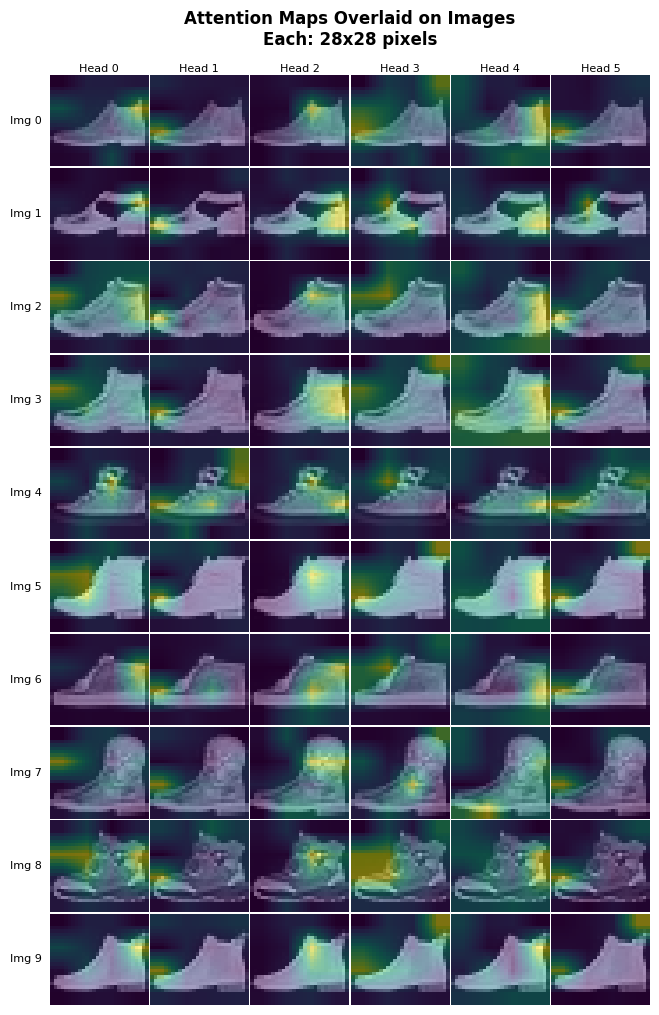

In [57]:
coding_rate_list, sparsity_list, block_outputs_list, w_list = setup_model_hooks(model)

# Select a batch of 10 images of class 9 from the test set
num_samples = 10
class_idx = 9

# Get indices of test dataset for class 9
indices_class9 = [i for i, (_, label) in enumerate(test_dataset) if label == class_idx][:num_samples]
images = torch.stack([test_dataset[i][0] for i in indices_class9]).to(device)

with torch.no_grad():
    outputs = model(images)

attention_upsampled, attention_upsampled_np, images_denorm_np = visualize_cls_attention_maps(
    w_list, images, model_config, 
    mean=0.2860, std=0.3530, verbose=True, show_plot=True
)

Original last block embeddings shape: torch.Size([10, 17, 36])
Rearranged last block embeddings shape: torch.Size([10, 6, 17, 6])
CLS token shape: torch.Size([10, 6, 6])
Other patches shape: torch.Size([10, 6, 16, 6])
CLS similarities (dot product) shape: torch.Size([10, 6, 16])
CLS attention weights (softmax) shape: torch.Size([10, 6, 16])
CLS attention weights sum per batch and head (should be ~1.0):
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])
Original atte

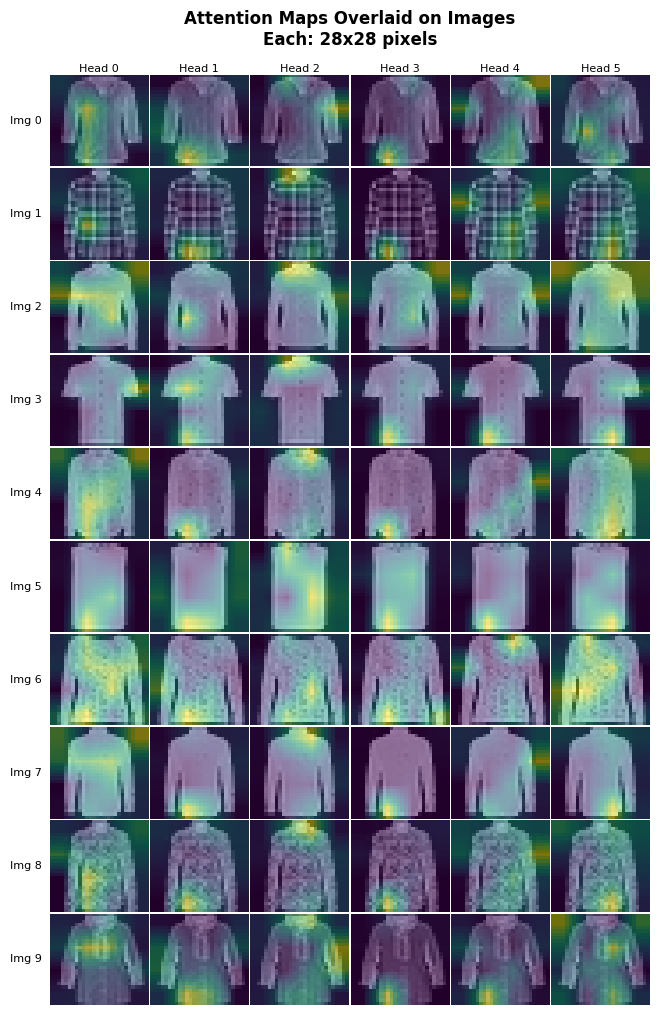

In [68]:
coding_rate_list, sparsity_list, block_outputs_list, w_list = setup_model_hooks(model)

# Select a batch of 10 images of class 9 from the test set
num_samples = 10
class_idx = 6

# Get indices of test dataset for class 9
indices_class9 = [i for i, (_, label) in enumerate(test_dataset) if label == class_idx][:num_samples]
images = torch.stack([test_dataset[i][0] for i in indices_class9]).to(device)

with torch.no_grad():
    outputs = model(images)

attention_upsampled, attention_upsampled_np, images_denorm_np = visualize_cls_attention_maps(
    w_list, images, model_config, 
    mean=0.2860, std=0.3530, verbose=True, show_plot=True
)